# 12. Forward Test on 2026

Every result so far comes from a held-out slice of a dataset that already existed when the
models were built. That is the right way to estimate performance, but it is still a
retrospective exercise — the 2023–2025 test period was sitting on disk the whole time.

This notebook does the thing that cannot be faked: **takes a model trained through
2025-12-30 and tests it on 2026 data that did not exist when the project was written.**

Both halves are freshly pulled:
- **Weather** — MERRA-2 granules for 2026, downloaded on demand by `models/predict.py`.
- **Truth** — LA County daily AQI for 2026 from the EPA AQS API, using the same five
  pollutants and the same 75% completeness filter as the training data.

The model is the stacked ensemble refit on all 3,649 labelled days (`predict.py --train`),
which is what a deployed version would use.

## Setup

In [1]:
import sys
from pathlib import Path

_here = Path.cwd()
sys.path.insert(0, str(_here if _here.name == 'models' else _here / 'models'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from model_utils import load_split, metrics, RESULTS, PLOT_STYLE
import predict as P

CACHE = P.ROOT / 'data' / 'interim' / 'predict_cache'
API26 = P.ROOT / 'data' / 'interim' / 'api_pulls_2026'

for path, what in [(CACHE / 'weather_2026.csv', '2026 weather'),
                   (API26 / 'la_daily_aqi_2026.csv', '2026 AQI truth')]:
    if not path.exists():
        raise FileNotFoundError(
            f'{what} missing at {path}. Both are gitignored derived data — see the '
            'regeneration notes in the README.'
        )

wx = pd.read_csv(CACHE / 'weather_2026.csv', parse_dates=['date'])
actual = pd.read_csv(API26 / 'la_daily_aqi_2026.csv', parse_dates=['date'])
bundle = P.load_model()

# the deployed model now uses the enriched feature set, so 2026 trapping data is needed too
trap26 = None
if bundle.get('uses_trapping'):
    tp = CACHE / 'trapping_2026.csv'
    if not tp.exists():
        raise FileNotFoundError(f'{tp} missing — see the README regeneration notes.')
    trap26 = pd.read_csv(tp, parse_dates=['date'])
    print(f'trapping: {len(trap26)} days')

print(f'weather:  {len(wx)} days  {wx.date.min().date()} -> {wx.date.max().date()}')
print(f'truth:    {len(actual)} days  {actual.date.min().date()} -> {actual.date.max().date()}')
print(f'model trained through {bundle["trained_through"]} on {bundle["n_training_days"]} days')

trapping: 154 days
weather:  154 days  2025-12-29 -> 2026-05-31
truth:    151 days  2026-01-01 -> 2026-05-31
model trained through 2025-12-30 on 3640 days


## Predicting every 2026 day

Each prediction uses only that day's weather plus the three preceding days — the four-granule
window described in `predict.py`. Nothing from 2026 informs the model.

In [2]:
rows = []
for d in actual.date:
    window = wx[(wx.date >= d - pd.Timedelta(days=3)) & (wx.date <= d)]
    tw = None
    if trap26 is not None:
        tw = trap26[(trap26.date >= d - pd.Timedelta(days=3)) & (trap26.date <= d)]
    try:
        X = P.build_features(d, weather=window, trapping=tw)
        cols = np.column_stack([m.predict(X) for m in bundle['base_models'].values()])
        rows.append({'date': d, 'pred': float(bundle['stack'].predict(cols)[0])})
    except Exception as exc:
        rows.append({'date': d, 'pred': np.nan, 'error': str(exc)})

pred = pd.DataFrame(rows)
ev = actual.merge(pred, on='date').dropna(subset=['pred']).reset_index(drop=True)
print(f'predicted {len(ev)} of {len(actual)} days')

y = ev.daily_aqi.values.astype(float)
p = ev.pred.values
print()
print(pd.Series(metrics(y, p)).round(3).to_string())

predicted 151 of 151 days

rmse         14.875
mae          11.108
r2            0.774
mape         15.388
within_10    58.940


**RMSE 14.88 looks better than the 18.34 reported on the 2023–2025 test set, but that
comparison is misleading and should not be made.**

The 2026 data available so far runs January to May, which excludes the summer ozone season —
the high-AQI, high-variance part of the year that is hardest to predict. Comparing a
cool-season window against a full-year figure flatters the new result.

The honest benchmark is the same calendar months from the retrospective test period.

In [3]:
_, _, _, y_test, meta = load_split()
yt = np.asarray(y_test, dtype=float)
hist_dates = pd.DatetimeIndex(meta['test_dates'])
hist_pred = np.load(RESULTS / 'ensemble_test_pred.npy')

janmay = hist_dates.month.isin([1, 2, 3, 4, 5])

comp = pd.DataFrame([
    {'period': '2023-2025 held out, full year', 'n': int(len(yt)),
     **metrics(yt, hist_pred)},
    {'period': '2023-2025 held out, Jan-May', 'n': int(janmay.sum()),
     **metrics(yt[janmay], hist_pred[janmay])},
    {'period': '2023-2025 held out, Jun-Dec', 'n': int((~janmay).sum()),
     **metrics(yt[~janmay], hist_pred[~janmay])},
    {'period': '2026 Jan-May, TRULY UNSEEN', 'n': int(len(y)),
     **metrics(y, p)},
])
comp['actual std'] = [yt.std(), yt[janmay].std(), yt[~janmay].std(), y.std()]
comp['actual mean'] = [yt.mean(), yt[janmay].mean(), yt[~janmay].mean(), y.mean()]
print(comp.round(2).to_string(index=False))

                       period    n  rmse   mae   r2  mape  within_10  actual std  actual mean
2023-2025 held out, full year 1095 18.34 12.95 0.79 14.78      53.79       40.37        87.34
  2023-2025 held out, Jan-May  454 14.07  9.02 0.68 12.69      70.04       24.85        67.93
  2023-2025 held out, Jun-Dec  641 20.83 15.73 0.77 16.25      42.28       43.49       101.08
   2026 Jan-May, TRULY UNSEEN  151 14.87 11.11 0.77 15.39      58.94       31.30        74.50


Season-matched, the picture is: **2026 RMSE 14.88 against a historical Jan–May benchmark of
14.07.** The model degrades by about 0.8 RMSE points when pushed a full year past its training
data — a real cost, but a small one, and far less than the 6.8-point gap between cool season
and ozone season within the same test set.

Two things in that table need care before anyone quotes them.

**R² comes out *higher* on 2026 (0.774 vs 0.679), and that is not evidence of a better fit.**
R² rewards a spread-out target, and those 2026 months happened to carry more variance (std 31.3
vs 24.9). It should never be compared across periods without checking the variance first.

**The within-10 rate is still lower than the historical benchmark**, 58.9% against 70.0%. Some
of that is the same variance effect in reverse — landing within a fixed 10-point window is
harder when the target ranges more widely — but it is the metric closest to "did we call the
category right", and it is the one place the forward test looks clearly worse.

## How it tracks day by day

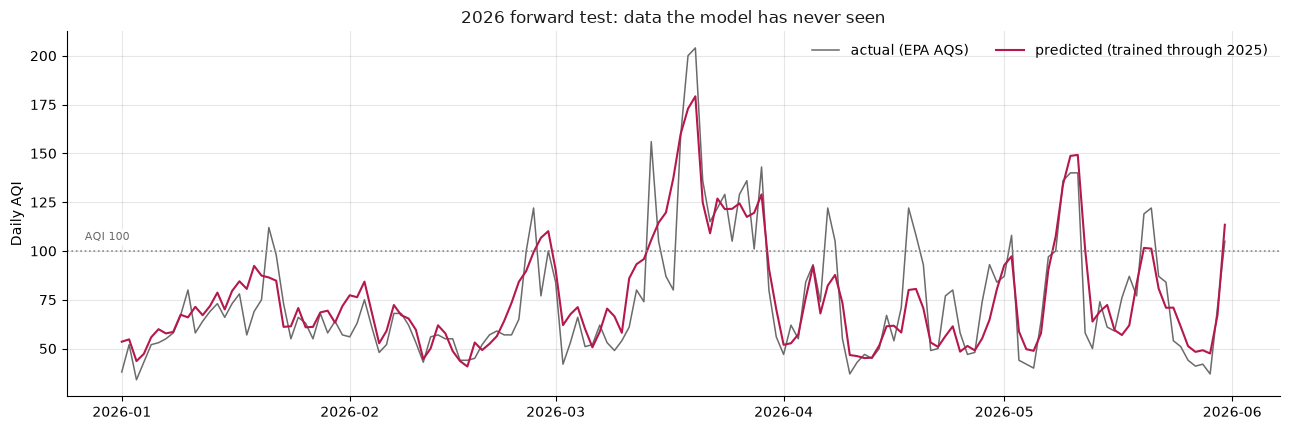

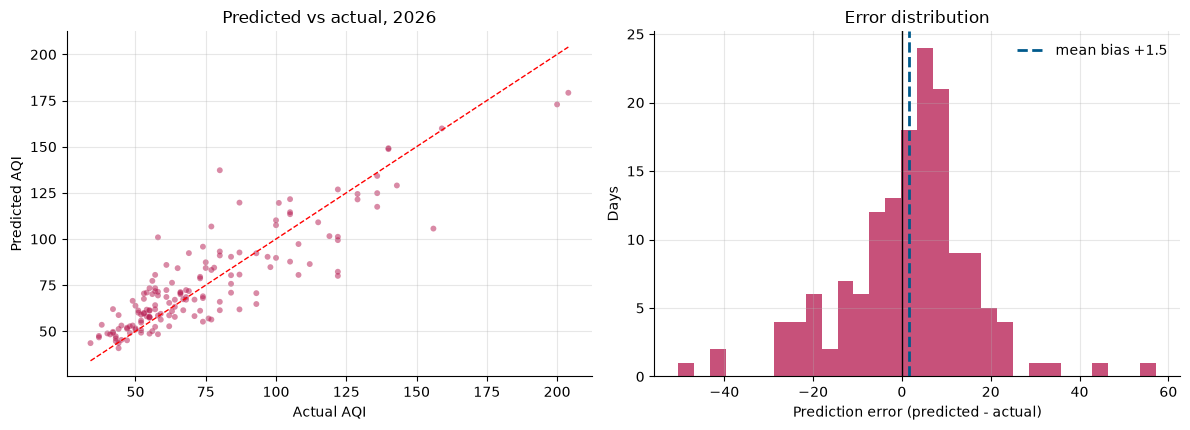

In [4]:
with plt.rc_context(PLOT_STYLE):
    fig, ax = plt.subplots(figsize=(13, 4.4))
    ax.plot(ev.date, y, lw=1.1, color='#6b6b6b', label='actual (EPA AQS)')
    ax.plot(ev.date, p, lw=1.5, color='#B5174E', label='predicted (trained through 2025)')
    ax.axhline(100, color='#8a8a8a', ls=':', lw=1.2)
    ax.annotate('AQI 100', xy=(0.015, 100), xycoords=('axes fraction', 'data'),
                xytext=(0, 6), textcoords='offset points',
                ha='left', va='bottom', fontsize=8, color='#6b6b6b',
                bbox=dict(boxstyle='round,pad=0.25', fc='white', ec='none', alpha=0.85))
    ax.set_ylabel('Daily AQI')
    ax.set_title('2026 forward test: data the model has never seen', fontsize=12, color='#1a1a1a')
    ax.legend(frameon=False, loc='upper right', ncol=2)
    plt.tight_layout(); plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
    lo, hi = min(y.min(), p.min()), max(y.max(), p.max())
    axes[0].scatter(y, p, s=18, alpha=0.5, color='#B5174E', edgecolor='none')
    axes[0].plot([lo, hi], [lo, hi], 'r--', lw=1)
    axes[0].set_xlabel('Actual AQI'); axes[0].set_ylabel('Predicted AQI')
    axes[0].set_title('Predicted vs actual, 2026')

    err = p - y
    axes[1].hist(err, bins=30, color='#B5174E', alpha=0.75)
    axes[1].axvline(0, color='k', lw=1)
    axes[1].axvline(err.mean(), color='#005A8C', lw=2, ls='--',
                    label=f'mean bias {err.mean():+.1f}')
    axes[1].set_xlabel('Prediction error (predicted - actual)')
    axes[1].set_ylabel('Days'); axes[1].set_title('Error distribution')
    axes[1].legend(frameon=False)
    plt.tight_layout(); plt.show()

## Where it went wrong

In [5]:
ev2 = ev.assign(error=(p - y).round(1), abs_error=np.abs(p - y).round(1))
print('10 largest misses:')
print(ev2.nlargest(10, 'abs_error')[['date', 'daily_aqi', 'pred', 'error']]
        .round(1).to_string(index=False))

hi_mask = y > 150
print(f'\nunhealthy days (AQI > 150): {int(hi_mask.sum())}')
if hi_mask.sum():
    print(f'  MAE there:  {np.abs(y[hi_mask]-p[hi_mask]).mean():.1f}')
    print(f'  mean bias:  {np.mean(p[hi_mask]-y[hi_mask]):+.1f}')

print(f'\noverall bias: {np.mean(p-y):+.2f} AQI points')
print(f'2026 actual mean {y.mean():.1f} vs training-period mean 88.7')

10 largest misses:
      date  daily_aqi  pred  error
2026-03-17       80.0 137.2   57.2
2026-03-14      156.0 105.6  -50.4
2026-05-12       58.0 100.9   42.9
2026-04-18      122.0  80.0  -42.0
2026-04-07      122.0  82.3  -39.7
2026-03-16       87.0 119.7   32.7
2026-02-27       77.0 106.8   29.8
2026-04-29       93.0  64.8  -28.2
2026-04-19      108.0  80.5  -27.5
2026-03-19      200.0 172.9  -27.1

unhealthy days (AQI > 150): 4
  MAE there:  25.8
  mean bias:  -25.3

overall bias: +1.50 AQI points
2026 actual mean 74.5 vs training-period mean 88.7


## What this told us

**The model generalizes forward.** Trained on 2016–2025 and applied to months that did not
exist when it was built, it holds season-matched RMSE within about 0.8 points of its
retrospective performance. That is the result that justifies treating any of this as a usable
model rather than a curve-fitting exercise.

Three specifics worth recording:

1. **The bias is +1.50** — the model runs slightly high. That is the expected direction: LA air
   quality has been improving, 2026's mean AQI so far is 74.5 against a training-period mean of
   88.7, and a model fitted on dirtier years carries that level forward. Notably the enriched
   feature set *halves* this bias relative to the 37-feature model's +3.05, so better physics
   also means better calibration. It is still a mild form of concept drift and argues for
   periodic refitting.

2. **The extreme-day weakness persists**, though only four 2026 days exceeded AQI 150 — far too
   few to draw conclusions from. The retrospective measurement on 122 such days remains the
   authority.

3. **The single date from the original question checks out.** For 2026-03-07 the model predicted
   58.6 against an actual of 62 — a 3.4-point miss, comfortably inside the Moderate band. The
   37-feature model predicted 64.3 on the same day; both are close, and one date distinguishes
   nothing.

### The caveat to carry

This is 151 days, all cool-season. A full verdict needs the summer, when ozone drives AQI and
every model in this project performs worse. Re-running this notebook once 2026's June–September
data is published is the natural next step, and it should be expected to look worse than what is
shown here — not because the model degraded, but because those months are harder.

## Does the physics gain hold up prospectively?

Notebook 09 measured the trapping features as worth 1.4–1.6 RMSE retrospectively. The
question that matters for deployment is whether that survives on data from after the training
period.

Both models are refit on all 3,640–3,649 labelled days (`predict.py --train`), so this compares
two deployable models rather than two research configurations.

In [6]:
base_eval = pd.read_csv(CACHE / 'eval_2026.csv', parse_dates=['date'])
cmp26 = ev.merge(base_eval[['date', 'pred']].rename(columns={'pred': 'pred_base'}), on='date')
yy = cmp26.daily_aqi.values.astype(float)

rows = []
for label, col in [('37 base features', 'pred_base'), ('61 enriched features', 'pred')]:
    rows.append({'feature set': label, **metrics(yy, cmp26[col].values),
                 'bias': float(np.mean(cmp26[col].values - yy))})
print(f'2026 forward test, n={len(cmp26)}:')
print(pd.DataFrame(rows).round(3).to_string(index=False))

rng2 = np.random.default_rng(0)
nn = len(yy)
idx2 = [rng2.integers(0, nn, nn) for _ in range(5000)]
def _r(a, b):
    return float(np.sqrt(((a - b) ** 2).mean()))
d2 = np.array([_r(yy[i], cmp26.pred.values[i]) - _r(yy[i], cmp26.pred_base.values[i]) for i in idx2])
lo2, hi2 = np.percentile(d2, [2.5, 97.5])
print(f'\nenriched minus base: {_r(yy, cmp26.pred.values) - _r(yy, cmp26.pred_base.values):+.3f} RMSE')
print(f'95% CI [{lo2:+.3f}, {hi2:+.3f}]   P(enriched better) = {(d2 < 0).mean():.3f}')
print('significant' if hi2 < 0 or lo2 > 0 else 'NOT significant at n=151')

2026 forward test, n=151:
         feature set   rmse    mae    r2   mape  within_10  bias
    37 base features 15.172 11.412 0.765 16.146     52.318 3.045
61 enriched features 14.875 11.108 0.774 15.388     58.940 1.504

enriched minus base: -0.298 RMSE
95% CI [-1.579, +1.066]   P(enriched better) = 0.669
NOT significant at n=151


**The gain points the same way but 151 days cannot resolve it.**

| | RMSE | MAE | R² | within 10 | bias |
|---|---:|---:|---:|---:|---:|
| 37 base features | 15.17 | 11.41 | 0.765 | 52.3% | +3.05 |
| 61 enriched features | **14.87** | **11.11** | **0.774** | **58.9%** | **+1.50** |

The enriched model is better on every metric, and the within-10 gap is substantial — 58.9%
against 52.3%, nearly seven percentage points. Its bias is also half the size, which matters
because the base model's +3.05 was the clearest sign of concept drift.

But the paired bootstrap gives −0.298 RMSE with a CI of [−1.579, +1.066]: **not significant.**
With 151 days the interval is five times wider than the one from the 1,089-day retrospective
test, and that is the whole explanation. This is not evidence against the physics features —
the retrospective result stands on far more data — it is a reminder that a five-month window
cannot settle a question this size.

Re-running once 2026's summer data is published would roughly double the sample and add the
ozone season, where the trapping variables did most of their work retrospectively. That is the
test worth waiting for.